In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import os
import pandas as pd
plt.style.use(['science','notebook','grid'])
from datetime import datetime as dt
import importlib


## Import src plotting methods

In [2]:
from src import plotting_toolkit as pt
#from src.plotting_toolkit import show_setup as ss
importlib.reload(pt)

<module 'src.plotting_toolkit' from 'c:\\FAKS\\MAGISTERIJ\\4. semester\\ZF - zdravstvnea_fizika\\simulacije\\1-Bulid-up faktor\\main\\analysis\\src\\plotting_toolkit.py'>

---
---
# Analyse processed simulation data
- data saved as csv file
- use pandas dataframe (pd.read_csv)
- use pd.methods to analyse
- use Data Wrangler

---
---

#                READ DATA FROM STORAGE (/data/processed)

---
---

In [3]:
filepath = "../data/processed"
input_filename = "processed_2to14hvl.csv"
# read processed csv data into dataframe
df = pd.read_csv(f"{filepath}/{input_filename}")

In [82]:
df
#df.keys()

,method,E0,n_hvl,t_sim,B_mean,B_std,Nsec_mean,Nsec_std,Nprim_mean,Nprim_std,stps_per_ph,Nsim_per_sec,FOM
0,combine,0.10,2,0.572715,1.008865,0.000338,1230,33.963789,0.000000,0.000000,2.042331,17293.661130,1.528311e+07
1,forcing,0.10,2,0.514213,1.008879,0.000198,1792,38.150519,0.000000,0.000000,2.061801,19189.848264,4.954322e+07
2,normal,0.10,2,0.087454,1.009024,0.018188,24,4.804154,2500.000000,44.786587,1.014281,111730.188317,3.456625e+04
3,pdf,0.10,2,0.101226,1.009534,0.012991,28,5.464634,4960.780000,51.864154,1.009487,97459.582657,5.853705e+04
4,combine,0.25,2,0.778557,1.057743,0.001013,2880,42.519391,0.000000,0.000000,2.304671,12667.857050,1.252431e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,pdf,10.00,12,143.664302,2.302987,0.019308,17930,104.474718,11161.000000,78.747698,3.882421,6927.857363,1.867070e+01
192,combine,10.00,14,361.752341,2.752831,0.022220,10056,72.386923,0.000000,0.000000,6.778301,2754.842802,5.598917e+00
193,forcing,10.00,14,417.230443,2.776153,0.083566,437,15.613029,0.000000,0.000000,7.567654,2388.470462,3.432118e-01
194,normal,10.00,14,141.078260,2.579380,0.090690,342,22.160024,55.000000,4.690416,3.983709,7069.555276,8.618227e-01


 ---
# Define functions for plotting 

## Refresh modules using importlib 

In [33]:
importlib.reload(pt)

<module 'src.plotting_toolkit' from 'c:\\FAKS\\MAGISTERIJ\\4. semester\\ZF - zdravstvnea_fizika\\simulacije\\1-Bulid-up faktor\\main\\analysis\\src\\plotting_toolkit.py'>

---
---
# Plotting
---

### Show setup

In [ ]:
E0 = [0.1,0.2,0.5,1.0,2.0,5.0,10.0] [2]
n_hvl = 10

pt.show_setup(df, E0=E0, n_hvl=n_hvl)                 # compare all methods at one setup
#show_setup(summary, E0=E0, n_hvl_x=n_hvl_x, method="pdf")   # single method

,method,E0,n_hvl,t_sim,B_mean,B_std,FOM
164,combine,0.5,10,158.730977,1.582025,0.003617,481.642974
165,forcing,0.5,10,172.547138,1.568966,0.012035,40.014875
166,normal,0.5,10,36.219880,1.562994,0.032672,25.864627
167,pdf,0.5,10,38.064297,1.577986,0.010442,240.964261


### Plot B(n_hvl)

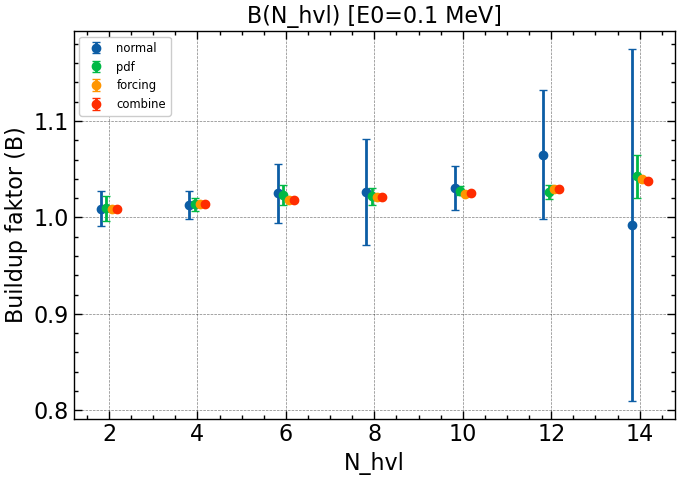

In [25]:
importlib.reload(pt)
#methods_used = ["all"] #* tu je problem vrstni red
methods_used = ["normal", "pdf", "forcing", "combine"]
#methods_used = ["normal", "pdf", "forcing"]

E0 = 0.1
pt.plot_B_vs_hvl(df, E0=E0, methods_used=methods_used,
                 #save_path = "../figures/B_vs_hvl_0.1MeV.png"
                 )

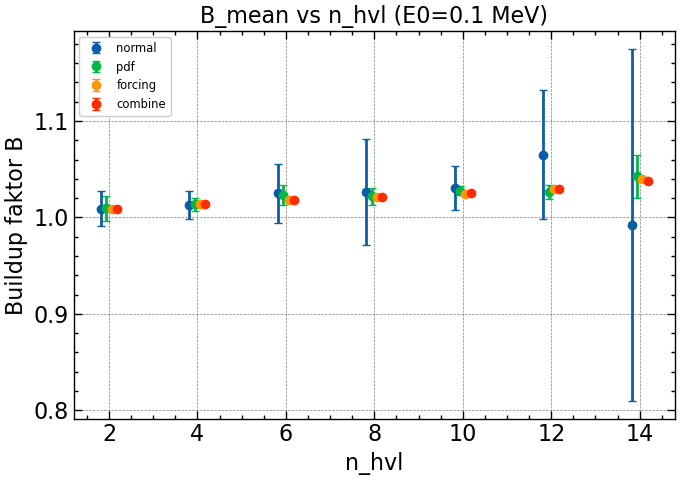

In [41]:
npt.plot_metric_vs_hvl(
    df, 
    E0=E0, 
    y="B_mean",
    #yscale="l",
    linestyle="none",
    marker="o",
    figsize=(7,5),
    save_path = "../figures/FOM_vs_hvl_0.1MeV.png"
)

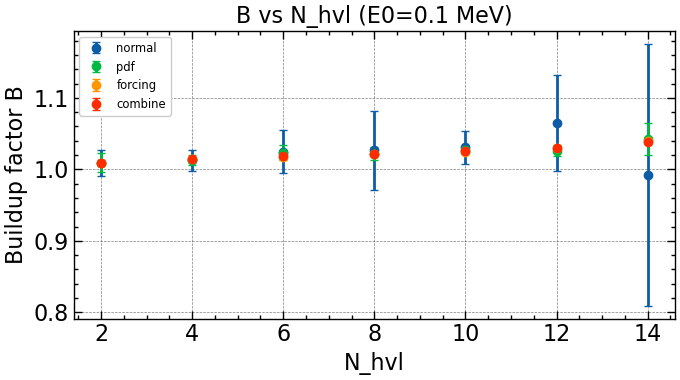

In [31]:
#methods_used = ["normal", "pdf", "forcing", "combine"]
#methods_used = ["normal", "pdf", "forcing"]

E0 = 0.1
npt.plot_B_vs_hvl_single_E0_multiple_methods(
    df, 
    E0=E0,
    show_std = True,
    linestyle="none",
    #save_path = "../figures/B_vs_hvl_0.1MeV.png"
                 )

 ---
# Plot value vs Nhvl or E0
- values:
   - FOM 
   - tsim
   - B_mean +- std_B
   - Nsec_mean +- Nsec_std .... number of secondaries
   - Nprim_mean +- Nprim_std ... number of primaries
   - stps_per_ph
   - Nsim_per_sec
 - parameters:
   - n_hvl
   - E0
   - method

 ---
 ## Plot value vs HVL
 

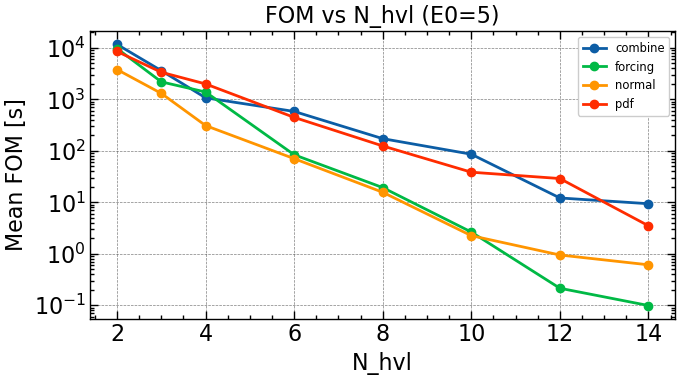

In [34]:
y_value = ["t_sim", "FOM", "B_mean","Nsec_mean","stps_per_ph","Nsim_per_sec"] [1]
E0 = 5
y_scale = ["log", "linear"] [0]

pt.plot_value_vs_hvl(df, E0, y_value=y_value, yscale=y_scale)

 ---
 # Plot value vs E0

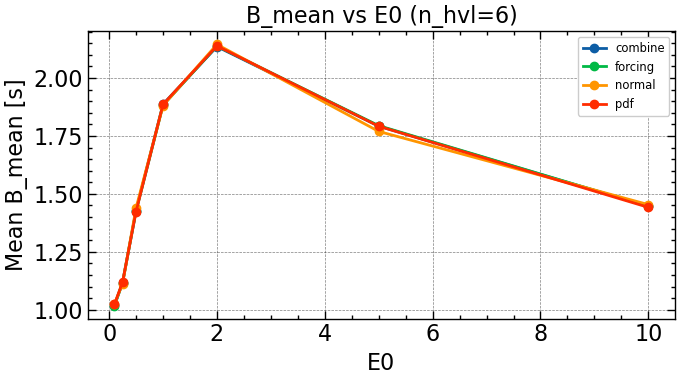

In [35]:
y_value = ["t_sim", "FOM", "B_mean","Nsec_mean", "Nsec_std","stps_per_ph","Nsim_per_sec"] [2]
n_hvl = 6
y_scale = ["log", "linear"] [1]
x_scale = ["log", "linear"] [1] #! important to onsied log(E0) scale for eg FOM graph...

pt.plot_value_vs_E0(df, n_hvl, y_value=y_value, yscale=y_scale, xscale=x_scale)

---
---
# 
---


In [55]:
# Map: which y_value has a corresponding std column
STD_MAP = {
    "B_mean": "B_std",
    "Nsec_mean": "Nsec_std",
    "Nprim_mean": "Nprim_std",
}

METHOD_ORDER = ["normal", "pdf", "forcing", "combine"]
METHOD_COLORS = {m: c for m, c in zip(METHOD_ORDER, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

def _apply_errorbars(ax, x, y, yerr, marker, color, label, linestyle="-"):
    """Unified errorbar call."""
    ax.errorbar(x, y, yerr=yerr, marker=marker, color=color,
                capsize=3, linestyle=linestyle, label=label)


def plot_value_vs_hvl(summary_df, E0, y_value="t_sim", yscale="log",
                      methods_used="all", show_errorbars=True, ax=None):
    sub = summary_df[summary_df["E0"] == E0].copy()
    if methods_used != "all":
        sub = sub[sub["method"].isin(methods_used)]

    method_order = [m for m in METHOD_ORDER if m in sub["method"].unique()]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4))

    std_col = STD_MAP.get(y_value) if show_errorbars else None

    for m in method_order:
        g = sub[sub["method"] == m].sort_values("n_hvl")
        yerr = g[std_col] if (std_col and std_col in g.columns) else None
        _apply_errorbars(ax, g["n_hvl"], g[y_value], yerr,
                         marker="o", color=METHOD_COLORS[m], label=m)

    ax.set_xlabel("n_hvl")
    ax.set_ylabel(y_value)
    ax.set_title(f"{y_value} vs n_hvl  (E0={E0} MeV)")
    ax.set_yscale(yscale)
    ax.legend(fontsize="small")

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_value_vs_E0(summary_df, n_hvl, y_value="t_sim", yscale="log", xscale="log",
                     methods_used="all", show_errorbars=True, ax=None):
    sub = summary_df[summary_df["n_hvl"] == n_hvl].copy()
    if methods_used != "all":
        sub = sub[sub["method"].isin(methods_used)]

    method_order = [m for m in METHOD_ORDER if m in sub["method"].unique()]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4))

    std_col = STD_MAP.get(y_value) if show_errorbars else None

    for m in method_order:
        g = sub[sub["method"] == m].sort_values("E0")
        yerr = g[std_col] if (std_col and std_col in g.columns) else None
        _apply_errorbars(ax, g["E0"], g[y_value], yerr,
                         marker="o", color=METHOD_COLORS[m], label=m)

    ax.set_xlabel("E0 [MeV]")
    ax.set_ylabel(y_value)
    ax.set_title(f"{y_value} vs E0  (n_hvl={n_hvl})")
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.legend(fontsize="small")

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_FOM_gain_vs_hvl(summary_df, E0, baseline="normal", yscale="log"):
    """FOM relative to baseline method."""
    sub = summary_df[summary_df["E0"] == E0].copy()
    base = sub[sub["method"] == baseline][["n_hvl", "FOM"]].rename(columns={"FOM": "FOM_base"})
    sub = sub.merge(base, on="n_hvl", how="left")
    sub["FOM_gain"] = sub["FOM"] / sub["FOM_base"]

    fig, ax = plt.subplots(figsize=(7, 4))
    method_order = [m for m in METHOD_ORDER if m in sub["method"].unique()]
    for m in method_order:
        g = sub[sub["method"] == m].sort_values("n_hvl")
        ax.plot(g["n_hvl"], g["FOM_gain"], marker="o",
                color=METHOD_COLORS[m], label=m)

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label=f"{baseline} (ref=1)")
    ax.set_xlabel("n_hvl")
    ax.set_ylabel(f"FOM / FOM_{baseline}")
    ax.set_title(f"FOM gain vs n_hvl  (E0={E0} MeV, baseline={baseline})")
    ax.set_yscale(yscale)
    ax.legend(fontsize="small")
    plt.tight_layout()
    plt.show()


def plot_grid_vs_hvl(summary_df, E0_list, y_value="B_mean", yscale="linear",
                     methods_used="all", show_errorbars=True):
    """One subplot per E0, all in a row."""
    n = len(E0_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, E0 in zip(axes, E0_list):
        plot_value_vs_hvl(summary_df, E0, y_value=y_value, yscale=yscale,
                          methods_used=methods_used, show_errorbars=show_errorbars, ax=ax)
        ax.get_legend().remove()

    # single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize="small")
    fig.suptitle(f"{y_value} vs n_hvl — multiple E0", y=1.02)
    plt.tight_layout()
    plt.show()

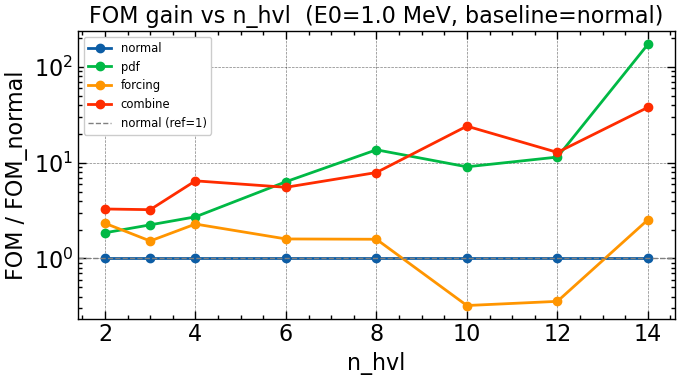

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


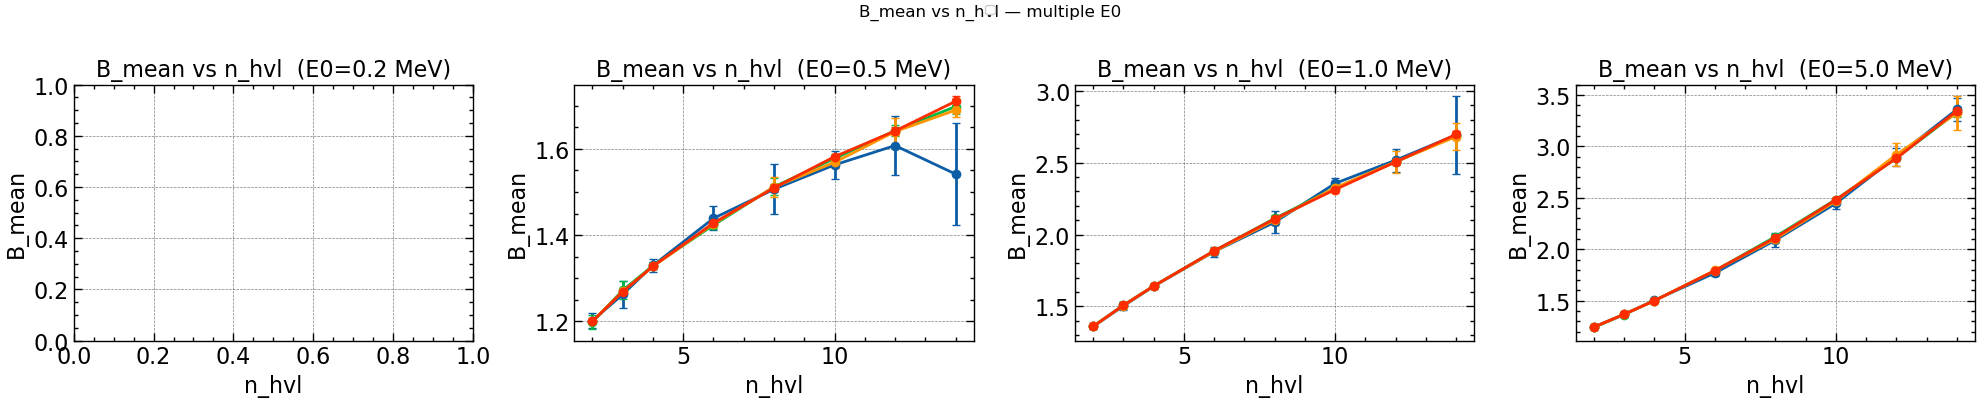

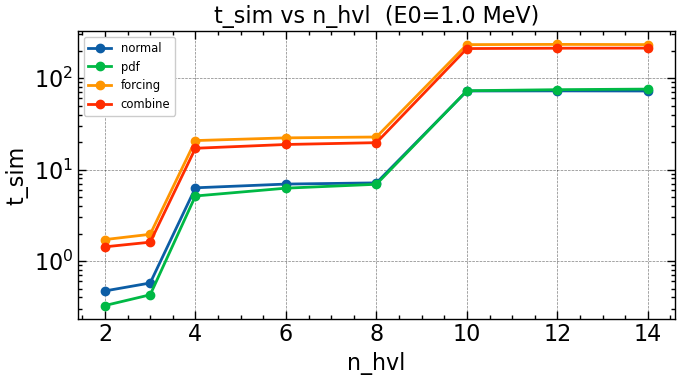

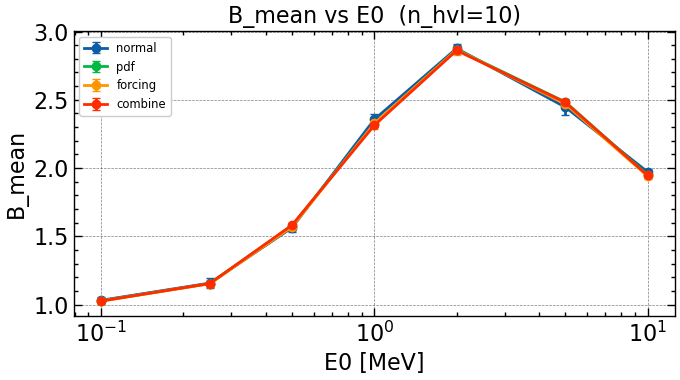

In [56]:
# FOM gain over normal MC
plot_FOM_gain_vs_hvl(df, E0=1.0)

# Grid: B(n_hvl) for several energies
plot_grid_vs_hvl(df, E0_list=[0.2, 0.5, 1.0, 5.0], y_value="B_mean", yscale="linear")

# t_sim with errorbars off (no std column for t_sim)
plot_value_vs_hvl(df, E0=1.0, y_value="t_sim", yscale="log", show_errorbars=False)

# B_mean with errorbars on E0 axis
plot_value_vs_E0(df, n_hvl=10, y_value="B_mean", yscale="linear", xscale="log")

---
---
# New plotting toolkit


In [27]:
import src.new_pt as npt
importlib.reload(npt)

<module 'src.new_pt' from 'c:\\FAKS\\MAGISTERIJ\\4. semester\\ZF - zdravstvnea_fizika\\simulacije\\1-Bulid-up faktor\\main\\analysis\\src\\new_pt.py'>

### Basic plots - not useful

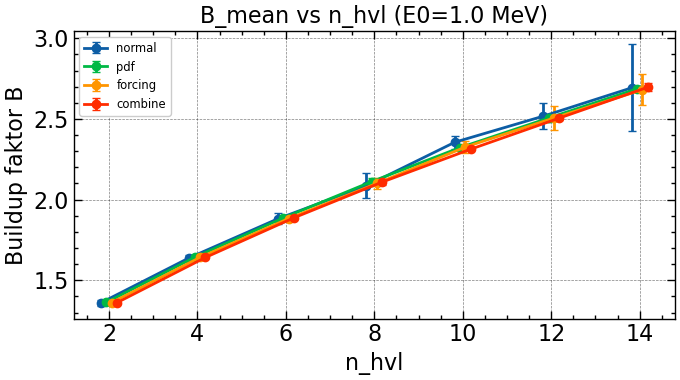

In [18]:
 #* plot B(Nhvl) for all methods
npt.plot_metric_vs_hvl(df, E0=1.0, y="B_mean", show_std=True, x_offset=True)
#npt.plot_metric_vs_hvl(df, E0=1.0, y="B_mean", show_std=False, linestyle="--", methods=["combine"])

# plot B with std on E0 axis
#npt.plot_metric_vs_E0(df, n_hvl=10, y="B_mean", show_std=True, xscale="log")

## B(Nhvl) for differnet E0

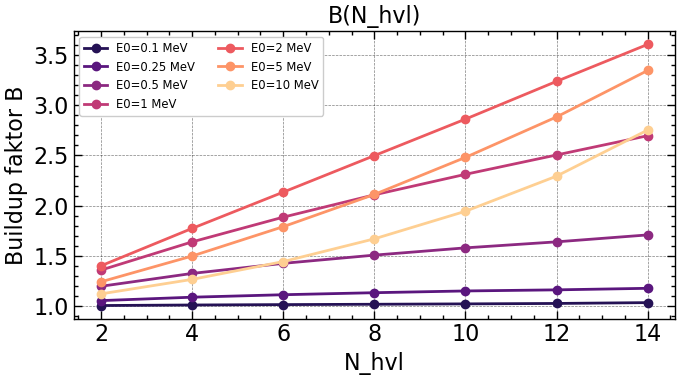

In [15]:
# all energies, one method
importlib.reload(npt)
cmap = ["cividis", "viridis", "plasma", "inferno", "magma"][4]  # choose a colormap
npt.plot_B_vs_hvl_multi_E0_single_method(
    df, 
    method="combine",
    cmap_name=cmap,
    grayscale_safe=False,
    #yscale="log"
    )

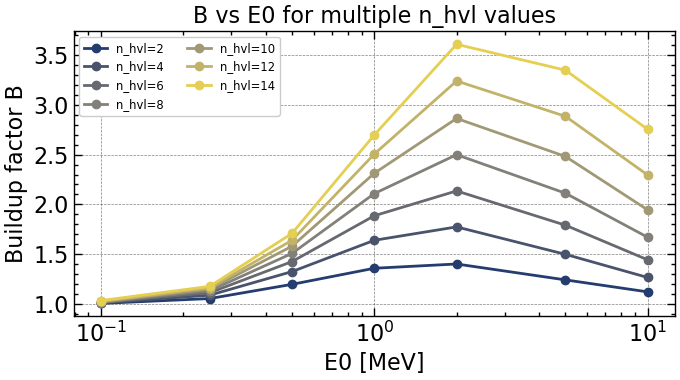

In [6]:
npt.plot_B_vs_E0_multi_nhvl_single_method(
    df,
    method="combine",
    nhvl_values=[2,4,6,8,10,12,14],
    xscale="log",
    yscale="linear",
    linestyle="-",
    marker="o",
    figsize=(7, 4),
    title="B vs E0 for multiple n_hvl values",
    save_path=None,
    cmap_name="cividis",
    grayscale_safe=False
)

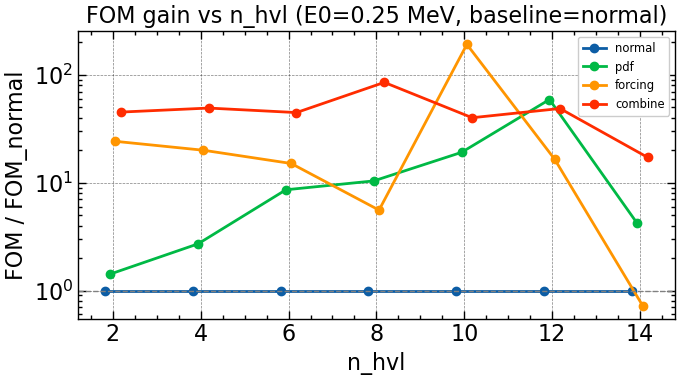

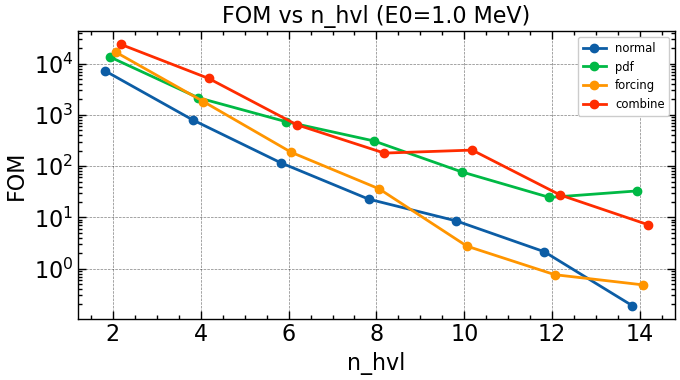

In [7]:
importlib.reload(npt)
# plot FOM gain over normal MC
npt.plot_FOM_gain_vs_hvl(df, E0=.25, baseline="normal", yscale="log", x_offset=True)
# plot FOM vs hvl
npt.plot_metric_vs_hvl(df, E0=1.0, y="FOM", show_std=False, yscale="log")

---
---
# Heatmaps

In [110]:
importlib.reload(npt)
# 2D parameter map; choose: 
# - method: normal, pdf, forcing, combine
# - value: "FOM", "B_mean", ...

<module 'src.new_pt' from 'c:\\FAKS\\MAGISTERIJ\\4. semester\\ZF - zdravstvnea_fizika\\simulacije\\1-Bulid-up faktor\\main\\analysis\\src\\new_pt.py'>

In [ ]:
method = "combine"
value = "FOM"
# ...

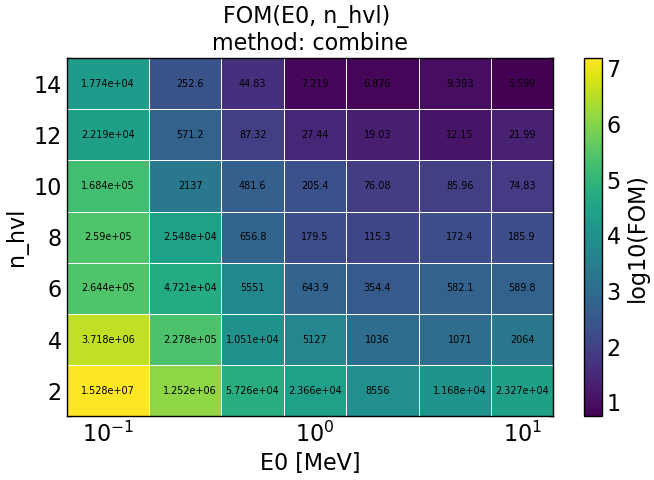

In [10]:
npt.plot_heatmap_E0_nhvl(df, method="combine", value="FOM", log_color=True)

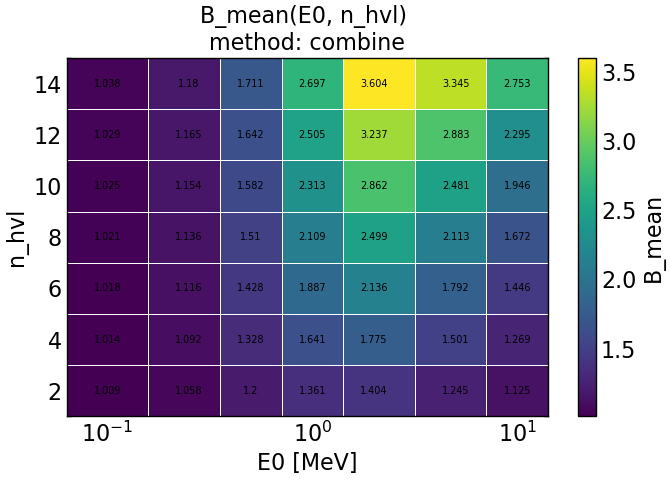

In [11]:
npt.plot_heatmap_E0_nhvl(df, method="combine", value="B_mean", log_color=False)

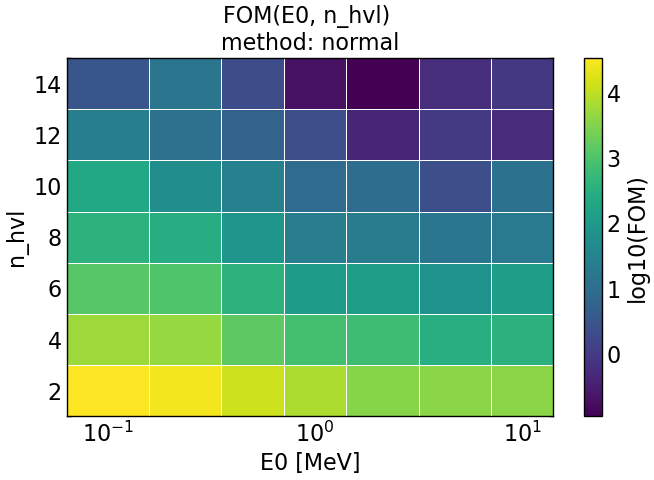

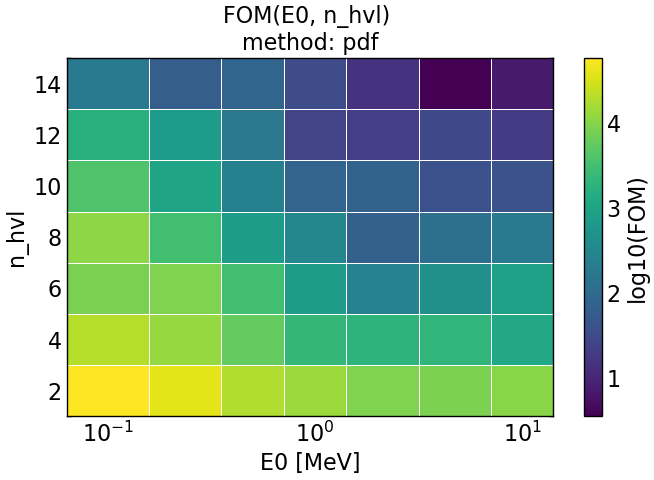

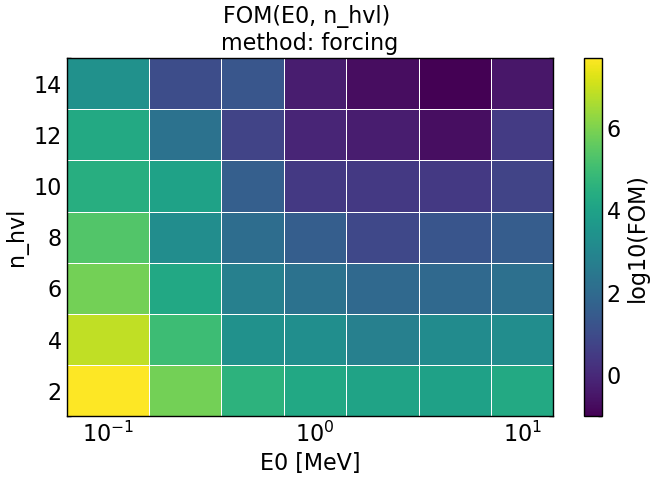

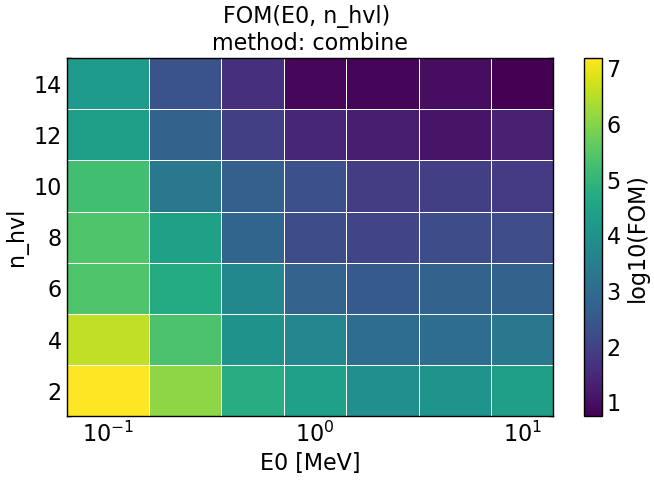

In [96]:
for m in ["normal", "pdf", "forcing", "combine"]:
    #* i) B - is the same for all method!
    #npt.plot_heatmap_E0_nhvl(df, method=m, value="B_mean", log_color=False)
    #* ii) FOM - different for each method, but similar pattern??
    npt.plot_heatmap_E0_nhvl(df, method=m, value="FOM", log_color=True)

---
---
## 3D plots (to develop)

c:\FAKS\MAGISTERIJ\4. semester\ZF - zdravstvnea_fizika\simulacije\1-Bulid-up faktor\main\analysis\src\new_pt.py:438: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


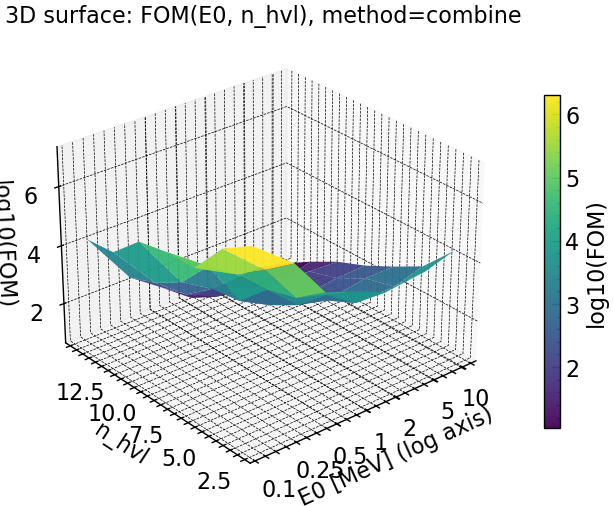

In [115]:
importlib.reload(npt)
npt.plot_surface_E0_nhvl(df, value="FOM", log_x=True,log_z = True)